The purpose of this notebook is to calculate how the irregular sampling of the timeseries of interest affect the power spectrum estimate. A second goal is to understand why very red signals converge to the spectral window with the same power.

In [2]:
from hydra import compose, initialize
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pathlib import Path
from astropy.timeseries import LombScargle
from methane_noise_forcing import io
from methane_noise_forcing import detrend_obs, calculate_mean_and_ci
from methane_noise_forcing.core import sample_ensemble_series, FirnFilter
from methane_noise_forcing.noise import simulate_two_timescale_ar1
from methane_noise_forcing.plotting.constants import (
    matplotlib_rcparams,
    fig_width_options,
    colors_vibrant,
    large_font,
)

plt.rcParams.update(matplotlib_rcparams)

In [28]:
psd_x_tick_labels = [1000, 100, 20, 10, 5, 1]

In [41]:
## load all obs
with initialize(
    version_base=None, config_path="../../configs"
):  # configs with data paths
    cfg = compose(config_name="config")

site_names = ["wdc05a", "wdc06a", "gisp2", "neem"]

## import data and power spectra
data = {}
power_spectra = {}
for site in site_names:
    data[site] = io.load_observational_data(site, **cfg.io[site].input)

    power_spectra[site] = xr.open_dataset(cfg.io[site].power_spectra_path)

2025-11-07 17:43:29,656 - methane_noise_forcing.io - INFO - Loading WDC05A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc05a.csv
2025-11-07 17:43:29,668 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv
2025-11-07 17:43:29,679 - methane_noise_forcing.io - INFO - Loading GISP2 data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_gisp2.csv
2025-11-07 17:43:29,690 - methane_noise_forcing.io - INFO - Loading NEEM data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/rhodesandbrook2019_neem.tab


# spectral window

## expected solution
The spectral window is given by the Fourier transform of the sampling function. For a set of sampling times \( t_i \), the sampling function can be represented as:
$
\begin{equation}
W(f) = \frac{1}{N} \left| \sum_{i=1}^{N} e^{-2 \pi i f t_i} \right|^2 
\end{equation}
$

In [42]:
def calc_spectral_window(times, freq, t0=None):
    """
    Return normalized spectral window |Σ exp(-2πi f (t - t0))|^2 / N^2.
    
    Parameters
    ----------
    times : array-like
        Sampling times.
    freq : array-like
        Frequencies at which to evaluate the spectral window.
    t0 : float, optional
        Reference time to center the phases. If None, uses min(times).
    """
    t = np.asarray(times, float)
    f = np.asarray(freq, float)
    if t0 is None:
        t0 = t.min()
    phase = np.exp(-2j * np.pi * f[:, None] * (t[None, :] - t0))
    W = np.abs(phase.sum(axis=1))**2 / (t.size**2)
    return W

In [43]:
period_eval_min = 1
period_eval_max = 1000
freq_eval = np.logspace(
    np.log10(1/period_eval_max), 
    np.log10(1/period_eval_min), 
    1000
)  # frequencies to evaluate spectral window

spectral_windows = {}
spectral_windows_smoothed = {}
for site in site_names:
    times = data[site]["gas_age"].values
    spectral_windows[site] = calc_spectral_window(times, freq_eval)
    # smooth spectral window with a moving average filter
    window_size = 20
    spectral_windows_smoothed[site] = np.convolve(
        spectral_windows[site], 
        np.ones(window_size)/window_size, 
        mode='same'
    )

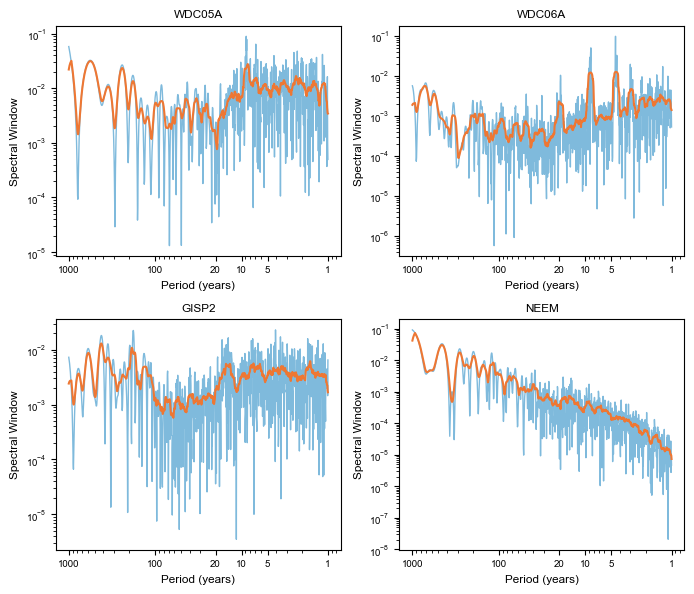

In [44]:
# plot empirical spectral windows
fig, axs = plt.subplots(
    nrows=2, ncols=2, figsize=(fig_width_options["two_column_large"], 6), tight_layout=True
)
axs = axs.flatten()

for i, site in enumerate(site_names):
    ax = axs[i]
    ax.plot(
        1 / freq_eval,
        spectral_windows[site],
        color=colors_vibrant["blue"],
        lw=1,
        alpha=0.5,
    )
    ax.plot(
        1 / freq_eval,
        spectral_windows_smoothed[site],
        color=colors_vibrant["orange"],
        # lw=2,
        # alpha=0.5,
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("Period (years)", fontsize=large_font)
    ax.set_ylabel("Spectral Window", fontsize=large_font)
    ax.set_title(site.upper(), fontsize=large_font)
    ax.set_xticks(psd_x_tick_labels)
    ax.set_xticklabels([f"{tick}" for tick in psd_x_tick_labels])
    ax.grid(False)